Linear baselines loaded.

Running Fixed QRF-IV...
Q25:
  Q25 h= 0: slope=+0.1019
  Q25 h=12: slope=+0.1468
  Q25 h=24: slope=+0.1867
  Q25 h=36: slope=+0.1952
  Q25 h=48: slope=+0.1857
Q50:
  Q50 h= 0: slope=+0.1002
  Q50 h=12: slope=+0.1504
  Q50 h=24: slope=+0.1867
  Q50 h=36: slope=+0.1920
  Q50 h=48: slope=+0.2006
Q75:
  Q75 h= 0: slope=+0.1037
  Q75 h=12: slope=+0.1460
  Q75 h=24: slope=+0.1958
  Q75 h=36: slope=+0.1822
  Q75 h=48: slope=+0.2154
Done.


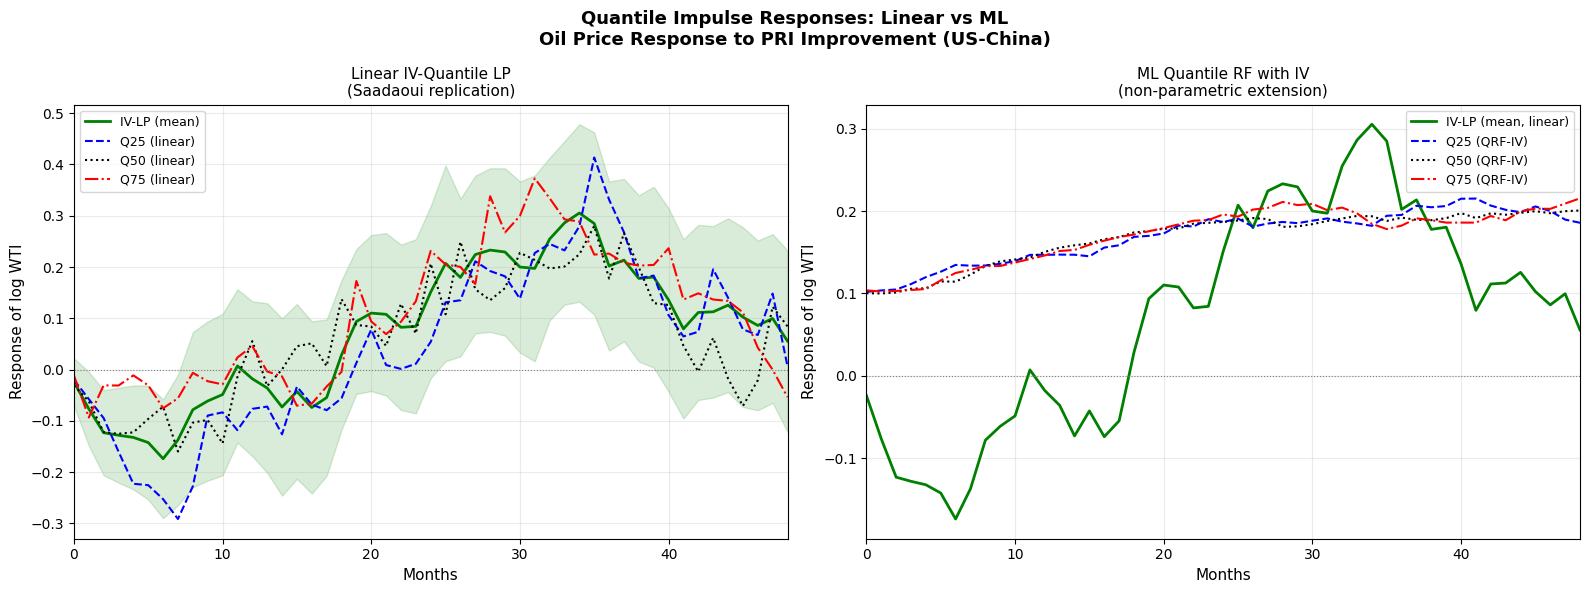

Saved: C:\Users\HP\Desktop\replication+contribution\figures\quantile_rf_fixed.png
Saved: results/quantile_rf_fixed.csv

=== Key horizons ===
   h   Q25 lin    Q25 ML   Q50 lin    Q50 ML   Q75 lin    Q75 ML
----------------------------------------------------------------
   0   -0.0199    0.1019   -0.0310    0.1002   -0.0114    0.1037
   6   -0.2529    0.1346   -0.0725    0.1142   -0.0755    0.1247
  12   -0.0767    0.1468    0.0554    0.1504    0.0456    0.1460
  18   -0.0561    0.1686    0.1374    0.1740   -0.0046    0.1714
  24    0.0540    0.1867    0.2068    0.1867    0.2314    0.1958
  30    0.1383    0.1883    0.2278    0.1840    0.2997    0.2087
  36    0.3313    0.1952    0.1774    0.1920    0.2262    0.1822
  42    0.0737    0.2066   -0.0043    0.1972    0.1487    0.1940
  48    0.0063    0.1857    0.0842    0.2006   -0.0538    0.2154


In [1]:
"""
03_quantile_rf_fixed.py

Fixed QRF-IV: extracts marginal effect via linear projection of predictions,
not perturbation. On n=380 with tree models, perturbation collapses to zero
because trees don't interpolate between observed values.

Correct approach: fit QRF, get predicted quantiles, then regress predictions
on T_hat to get the marginal effect (slope of prediction with respect to T).
This is the "partial dependence" slope, which is well-defined even for trees.
"""

import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

ROOT = Path(r"C:\Users\HP\Desktop\replication+contribution")
MODULE_PATH = ROOT / "replication" / "saadaoui_replication.py"
import importlib.util
spec = importlib.util.spec_from_file_location("saadaoui_replication", MODULE_PATH)
rep = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = rep
spec.loader.exec_module(rep)

p = rep.locate_paths()
df = rep.ensure_derived_columns(
    rep.load_data(p.dta, cache_path=p.cache / "Saadaoui_2026_JCE.parquet")
)
base_controls = ["llwip", "dllgop", "l2lwip", "dl2lgop"]
work, lag_cols = rep.add_lagged_controls(
    df, y_col="lwti", shock_col="lpri", y_lags=3, shock_lags=2
)
x_cols = lag_cols + base_controls

baseline = rep.lp_iv(df, "lpri", "d2pri", base_controls)
q25_lin  = rep.lp_quantile(df, "lpri", "d2pri", base_controls, q=0.25)
q50_lin  = rep.lp_quantile(df, "lpri", "d2pri", base_controls, q=0.50)
q75_lin  = rep.lp_quantile(df, "lpri", "d2pri", base_controls, q=0.75)
print("Linear baselines loaded.")

# ─────────────────────────────────────────────────────────────────────────────
# FIXED QRF-IV
# ─────────────────────────────────────────────────────────────────────────────

def quantile_rf_iv_fixed(df_work, x_cols, q, endog='lpri', instr='d2pri', hmax=48):
    """
    Stage 1: RF predicts T from [Z, X] -> T_hat, v_hat = T - T_hat
    Stage 2: GB quantile predicts Y from [T_hat, X, v_hat]

    Marginal effect extraction:
      Instead of perturbing T_hat by 1 unit (collapses on small n),
      we regress the GB predictions on T_hat using OLS.
      The OLS slope = marginal effect of T_hat on quantile of Y.
      This is well-defined because GB predictions are continuous.
    """

    rf_params = dict(n_estimators=200, max_depth=3,
                     min_samples_leaf=10, random_state=42, n_jobs=-1)

    irf = np.full(hmax + 1, np.nan)

    for h in range(hmax + 1):

        d = df_work.copy()
        d['y_fwd'] = d['lwti'].shift(-h)
        needed = ['y_fwd', endog, instr] + x_cols
        d = d[needed].replace([np.inf, -np.inf], np.nan).dropna()

        if len(d) < 80:
            continue

        Y  = d['y_fwd'].values
        T  = d[endog].values
        Z  = d[instr].values
        X  = d[x_cols].values
        ZX = np.column_stack([Z, X])

        # Stage 1: RF first stage -> T_hat and v_hat
        rf_fs = RandomForestRegressor(**rf_params)
        rf_fs.fit(ZX, T)
        T_hat = rf_fs.predict(ZX)
        v_hat = T - T_hat

        # Stage 2: GB quantile on [T_hat, X, v_hat]
        X2 = np.column_stack([T_hat, X, v_hat])

        gb_q = GradientBoostingRegressor(
            loss='quantile', alpha=q,
            n_estimators=200, max_depth=2,
            learning_rate=0.05, subsample=0.8,
            random_state=42
        )
        gb_q.fit(X2, Y)

        # Extract marginal effect: regress predictions on T_hat
        # OLS slope of yhat on T_hat = how much Q changes per unit of T
        y_pred = gb_q.predict(X2)
        ols = sm.OLS(y_pred, add_constant(T_hat, has_constant='add')).fit()
        slope = float(ols.params[1])
        irf[h] = slope

        if h % 12 == 0:
            print(f"  Q{int(q*100):02d} h={h:2d}: slope={slope:+.4f}")

    return irf


print("\nRunning Fixed QRF-IV...")
print("Q25:")
q25_ml = quantile_rf_iv_fixed(work, x_cols, q=0.25, hmax=48)
print("Q50:")
q50_ml = quantile_rf_iv_fixed(work, x_cols, q=0.50, hmax=48)
print("Q75:")
q75_ml = quantile_rf_iv_fixed(work, x_cols, q=0.75, hmax=48)
print("Done.")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────

horizons = np.arange(49)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle('Quantile Impulse Responses: Linear vs ML\n'
             'Oil Price Response to PRI Improvement (US-China)',
             fontsize=13, fontweight='bold')

# Left: linear quantile
ax = axes[0]
ax.plot(horizons, baseline['coef'].values[:49], color='green', linewidth=2, label='IV-LP (mean)')
ax.fill_between(horizons, baseline['lo90'].values[:49], baseline['hi90'].values[:49],
                color='green', alpha=0.15)
ax.plot(q25_lin['h'], q25_lin['coef'], '--', color='blue',  linewidth=1.5, label='Q25 (linear)')
ax.plot(q50_lin['h'], q50_lin['coef'], ':',  color='black', linewidth=1.5, label='Q50 (linear)')
ax.plot(q75_lin['h'], q75_lin['coef'], '-.', color='red',   linewidth=1.5, label='Q75 (linear)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Linear IV-Quantile LP\n(Saadaoui replication)', fontsize=11)
ax.set_xlabel('Months', fontsize=11)
ax.set_ylabel('Response of log WTI', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 48)
ax.grid(True, alpha=0.25)

# Right: ML quantile
ax = axes[1]
ax.plot(horizons, baseline['coef'].values[:49], color='green', linewidth=2, label='IV-LP (mean, linear)')
ax.plot(horizons, q25_ml, '--', color='blue',  linewidth=1.5, label='Q25 (QRF-IV)')
ax.plot(horizons, q50_ml, ':',  color='black', linewidth=1.5, label='Q50 (QRF-IV)')
ax.plot(horizons, q75_ml, '-.', color='red',   linewidth=1.5, label='Q75 (QRF-IV)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('ML Quantile RF with IV\n(non-parametric extension)', fontsize=11)
ax.set_xlabel('Months', fontsize=11)
ax.set_ylabel('Response of log WTI', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 48)
ax.grid(True, alpha=0.25)

plt.tight_layout()
out_fig = ROOT / 'figures' / 'quantile_rf_fixed.png'
plt.savefig(out_fig, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {out_fig}")

# Save
out = pd.DataFrame({
    'horizon':    horizons,
    'q25_linear': q25_lin['coef'].values[:49],
    'q50_linear': q50_lin['coef'].values[:49],
    'q75_linear': q75_lin['coef'].values[:49],
    'q25_mlrf':   q25_ml,
    'q50_mlrf':   q50_ml,
    'q75_mlrf':   q75_ml,
})
out.to_csv(ROOT / 'results' / 'quantile_rf_fixed.csv', index=False)
print("Saved: results/quantile_rf_fixed.csv")

# Print key horizons
print("\n=== Key horizons ===")
print(f"{'h':>4} {'Q25 lin':>9} {'Q25 ML':>9} {'Q50 lin':>9} "
      f"{'Q50 ML':>9} {'Q75 lin':>9} {'Q75 ML':>9}")
print("-" * 64)
for h in [0, 6, 12, 18, 24, 30, 36, 42, 48]:
    print(f"{h:>4} "
          f"{float(q25_lin.loc[q25_lin['h']==h,'coef'].iloc[0]):>9.4f} "
          f"{q25_ml[h]:>9.4f} "
          f"{float(q50_lin.loc[q50_lin['h']==h,'coef'].iloc[0]):>9.4f} "
          f"{q50_ml[h]:>9.4f} "
          f"{float(q75_lin.loc[q75_lin['h']==h,'coef'].iloc[0]):>9.4f} "
          f"{q75_ml[h]:>9.4f}")